<p class="mlx-kicker">Part I &middot; Anatomy &middot; Chapter 1</p>

# 1. Anatomy of a modern Transformer

<dl class="mlx-meta"><div><dt>Level</dt><dd>Introductory</dd></div><div><dt>Reading</dt><dd>about 20 min</dd></div><div><dt>Hands-on</dt><dd>about 6 min on a laptop CPU</dd></div><div><dt>You should know</dt><dd>Python, PyTorch tensors, matrix multiplication</dd></div></dl>


[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daiyip/ml-explained/blob/main/chapters/01-anatomy/index.ipynb)

![Anatomy of a modern Transformer, read bottom to top. Token ids (or image patches) become vectors of width d, flow through N identical blocks, and leave through a head. Shapes are written (B, T, d): batch size, sequence length, model width. Orange marks what the Vision Transformer changes: only the two ends and the attention mask.](figures/anatomy.svg)

## What each part does, and why it works

Until 2017 vision and language used different machines. Vision used **convolutional networks** (AlexNet, ResNet), which mix neighbouring pixels through small sliding filters. Language used **recurrent networks** (LSTMs), which read one token at a time and carry a running memory. The Transformer replaced both with one mechanism, attention, that *learns* which tokens should exchange information instead of hard-coding it. A modern language model and a modern vision model are now the same machine: tokens in, a stack of identical blocks, a small head out. Figure 1.1 shows both, read bottom to top, and the three tabs below walk up it: the input end, the repeated block, and the two ends that differ.

<div class="mlx-why">
<section class="mlx-why__card mlx-why__card--1"><p class="mlx-why__n">1 &middot; Into vectors</p><h3>Tokens become vectors that know their place</h3><p><b>What it does.</b> A tokenizer turns text into integer ids, and an embedding table maps each id to a learned vector of width <i>d</i>. RoPE then rotates the query and key vectors by an angle proportional to each token's position.</p><p><b>Why it works.</b> Attention compares tokens with dot products, which ignore where the vectors came from. After RoPE's rotation, the dot product between a query and a key depends only on how far apart they are, which is what attention needs to know about order.</p><p class="mlx-why__run">Our run: dot product 3.2858 at every pair two positions apart; removing RoPE raises the loss from 1.743 to 2.099</p></section>
<section class="mlx-why__card mlx-why__card--2"><p class="mlx-why__n">2 &middot; One block</p><h3>Mix across tokens, then within each token</h3><p><b>What it does.</b> Attention lets every token read from the tokens before it. The feed-forward layer then transforms each token on its own. RMSNorm rescales the input to each, and a residual connection adds each result back to a running sum, the residual stream.</p><p><b>Why it works.</b> Attention is the only route between tokens, so it carries all use of context. The feed-forward layer holds most of the parameters and acts like a memory. The residual path gives gradients a direct route through the whole stack, which is what makes depth trainable.</p><p class="mlx-why__run">Our run: without attention 2.492, without the residual path 3.355, against 1.743 for the full model</p></section>
<section class="mlx-why__card mlx-why__card--3"><p class="mlx-why__n">3 &middot; Two ends</p><h3>Swap the ends, keep the blocks</h3><p><b>What it does.</b> A Vision Transformer cuts an image into patches and embeds each one as a token. The blocks stay the same; only the causal mask is dropped, and the output head classifies the pooled patches instead of predicting the next token.</p><p><b>Why it works.</b> Attention assumes almost nothing about its input: no locality, no order. That costs data when data is scarce, but with enough data, learned structure beats the built-in assumptions of convolution and recurrence. <b>[likely]</b></p><p class="mlx-why__run">Our models: 803,712 parameters for text and 802,826 for images, with the same blocks</p></section>
</div>

Put together, the figure is the whole model: get the input into vectors, run the same block many times, and read out a prediction. Every later chapter takes one of these parts and traces how it evolved.

## Evolution path

| Year | Step | Level | What changed |
| --- | --- | --- | --- |
| 2012 | AlexNet | **major** | deep convolutional networks win on images |
| 2014 | Sequence-to-sequence LSTMs, then attention | **major** | recurrent networks for text; attention lets a decoder look back at the input |
| 2015 | ResNet | **major** | residual connections make very deep networks trainable |
| 2016 | Layer normalization | minor | normalize each token on its own, independent of the batch |
| 2017 | The Transformer | **major** | attention replaces recurrence; one block of attention plus feed-forward, repeated |
| 2018-2020 | GPT, BERT, GPT-3 | **major** | the same block, scaled up and pretrained on raw text |
| 2020 | Vision Transformer | **major** | images as patches; one architecture for text and vision |
| 2019-2021 | RMSNorm, SwiGLU, RoPE | minor | cheaper normalization, a gated feed-forward layer, rotary positions |
| 2023 | The Llama recipe | minor | pre-norm, RMSNorm, RoPE and SwiGLU become the default block, the one this chapter builds |

Each block has its own lineage chapter:

| Block | Its job | Evolution path | Chapter |
| --- | --- | --- | --- |
| Tokens and embeddings | turn input into vectors | one-hot, word2vec, BPE, image patches, multimodal tokens | 2 |
| Position | tell the model about order | implicit in convolution and recurrence, sinusoidal, learned, RoPE | 3 |
| Attention | mix information across tokens | convolution and recurrence, Bahdanau attention, multi-head self-attention, GQA, MLA | 4 |
| Feed-forward | transform each token | sigmoid MLP, ReLU, GELU, SwiGLU, Mixture of Experts | 5 |
| Normalization | keep activations in range | BatchNorm, LayerNorm, pre-norm, RMSNorm | 6 |
| Residual connections | make depth trainable | highway networks, ResNet, the residual stream | 7 |

The training recipe (loss, optimizer, learning-rate schedule, initialization) is chapters 8 to 11, and scale, post-training and inference are chapters 12 to 14.

## The lineage post-mortem: what drove each replacement?

| Replacement | Pressure that drove it | What it bought |
| --- | --- | --- |
| recurrence to attention | recurrent networks process tokens one after another and forget over long distances | every token reaches every earlier token in one step, and training runs in parallel |
| convolution to patches and attention | built-in locality limits what a vision model can learn from very large datasets | one architecture for images and text, which scales with data |
| plain stacks to residual connections | gradients fade through many layers | depth that trains reliably |
| post-norm to pre-norm with RMSNorm | deep Transformers diverged early in training | stable training with less tuning, and a cheaper norm |
| sinusoidal positions to RoPE | absolute positions say little about distance between tokens | a dot product that depends on relative distance |

Read top to bottom, the pressure moves from *what can the model see* (context, then images) to *can we train it deep and at scale*. Most of today's block was in place by 2017; what changed since is mostly about training it stably and cheaply.

**Still open:** whether attention's lack of built-in assumptions remains the right trade as data runs short; how much each block matters at frontier scale, since ablations like ours are run on small models; and how the residual stream organizes what the model knows.

## Run it yourself

Each step builds one part of the model and checks it, then the last step trains the whole thing on Shakespeare and removes one block at a time. Everything runs on a laptop CPU in about 10 minutes, or about 2 minutes on a free Colab GPU. The code is the same as in [`mlexp/transformer.py`](https://github.com/daiyip/ml-explained/blob/main/mlexp/transformer.py), which later chapters import and modify one block at a time.

In [1]:
# Setup: works from a checkout of the repo and on Google Colab.
import pathlib, subprocess, sys

try:
    import mlexp
except ImportError:
    root = pathlib.Path.cwd().resolve().parents[1]
    if (root / "mlexp").is_dir():
        sys.path.insert(0, str(root))
    else:  # Colab: install the shared helpers from GitHub
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/daiyip/ml-explained"], check=True)
    import mlexp

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
mlexp.setup_style()
device_note = "GPU available" if torch.cuda.is_available() else "running on CPU"
print(f"torch {torch.__version__}, {device_note}")

torch 2.14.1+cu130, running on CPU


### Step 1 (major): tokens, embeddings and position

#### Tokens and embeddings

A model cannot read characters, so text is first split into **tokens** and each token is mapped to an integer id. We use the simplest possible tokenizer, one token per character. (Real models use subword tokenizers such as BPE; that lineage is chapter 2.)

The **embedding** is a learned lookup table with one row of `d` numbers per token id. It turns `(B, T)` integers into `(B, T, d)` vectors, and it is the only place the model sees the raw identity of a token.

In [2]:
tok, train_ids, val_ids = mlexp.load_char_corpus()
print(f"vocabulary: {tok.vocab_size} characters, {len(train_ids):,} training tokens")
print("first 60 ids:", train_ids[:60].tolist())
print("decoded:     ", repr(tok.decode(train_ids[:60])))

embed = torch.nn.Embedding(tok.vocab_size, 128)
x = embed(train_ids[:64].unsqueeze(0))
print("embedding output shape (B, T, d):", tuple(x.shape))

vocabulary: 65 characters, 1,003,854 training tokens
first 60 ids: [18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0, 14, 43, 44, 53, 56, 43, 1, 61, 43, 1, 54, 56, 53, 41, 43, 43, 42, 1, 39, 52, 63, 1, 44, 59, 56, 58, 46, 43, 56, 6, 1, 46, 43, 39, 56, 1, 51, 43, 1, 57, 54, 43, 39, 49, 8]
decoded:      'First Citizen:\nBefore we proceed any further, hear me speak.'
embedding output shape (B, T, d): (1, 64, 128)


#### Position

Attention, as we will see, compares every token with every other token using dot products. A dot product does not care where the two vectors came from, so without help the model would treat a sentence as a bag of tokens.

Modern language models fix this with **RoPE** (rotary position embedding). Instead of adding a position vector to each token, RoPE *rotates* pairs of channels in the query and key vectors by an angle proportional to the token's position. When a rotated query meets a rotated key, the dot product depends only on how far apart they are, which is the information attention actually needs.

In [3]:
def apply_rope(x):
    """Rotary position encoding: rotate pairs of channels by a position-dependent angle.

    x has shape (batch, heads, seq, head_dim). Because queries and keys are both
    rotated, their dot product depends only on the distance between positions.
    """
    seq, dim = x.shape[-2], x.shape[-1]
    half = dim // 2
    freqs = 10000 ** (-torch.arange(half, device=x.device) / half)
    angles = torch.arange(seq, device=x.device)[:, None] * freqs[None, :]
    cos, sin = angles.cos(), angles.sin()
    x1, x2 = x[..., :half], x[..., half:]
    return torch.cat([x1 * cos - x2 * sin, x1 * sin + x2 * cos], dim=-1)

A quick check of that claim: rotate the same query and key at different absolute positions, keeping the distance between them fixed at 2. The dot product stays the same.

In [4]:
from mlexp.transformer import apply_rope

q, k = torch.randn(32), torch.randn(32)
seq = torch.stack([q] * 20)[None, None]  # (1, 1, 20, 32): q placed at every position
rot_q = apply_rope(seq)[0, 0]
rot_k = apply_rope(torch.stack([k] * 20)[None, None])[0, 0]
for m, n in [(2, 0), (9, 7), (19, 17)]:
    print(f"query at {m:2d}, key at {n:2d} (distance 2): dot = {rot_q[m] @ rot_k[n]:.4f}")
print(f"query at  5, key at  0 (distance 5): dot = {rot_q[5] @ rot_k[0]:.4f}")

query at  2, key at  0 (distance 2): dot = 3.2858
query at  9, key at  7 (distance 2): dot = 3.2858
query at 19, key at 17 (distance 2): dot = 3.2858
query at  5, key at  0 (distance 5): dot = 6.5057


### Step 2 (major): attention, mixing across tokens

Attention is the only place where tokens exchange information. Each token produces three vectors:

- a **query**: what am I looking for?
- a **key**: what do I contain?
- a **value**: what do I pass on if selected?

Each token's output is a weighted average of all values, weighted by how well its query matches each key (a softmax over dot products). **Multi-head** attention runs several of these lookups in parallel on slices of the vector, so different heads can track different relationships. The **causal mask** stops a language model from looking at future tokens it is supposed to predict.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: scaled dot-product attention</p><div class="mlx-eq">$$\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{QK^{\top}}{\sqrt{d_k}} + M\right) V$$</div><p class="mlx-eq__where">\(Q, K, V\) are the queries, keys and values of all tokens, \(d_k\) is the width of one head, and the causal mask \(M\) is \(0\) where a token may look and \(-\infty\) where it may not.</p></div>

In [5]:
class Attention(nn.Module):
    """Multi-head self-attention: every token looks up information from other tokens."""

    def __init__(self, dim: int, n_heads: int, causal: bool = True, rope: bool = True):
        super().__init__()
        self.n_heads, self.causal, self.rope = n_heads, causal, rope
        self.qkv = nn.Linear(dim, 3 * dim, bias=False)
        self.out = nn.Linear(dim, dim, bias=False)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=-1)
        q, k, v = (t.view(B, T, self.n_heads, C // self.n_heads).transpose(1, 2) for t in (q, k, v))
        if self.rope:
            q, k = apply_rope(q), apply_rope(k)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=self.causal)
        return self.out(y.transpose(1, 2).reshape(B, T, C))

In [6]:
from mlexp.transformer import Attention

attn = Attention(dim=128, n_heads=4)
y = attn(x)
print("attention keeps the shape:", tuple(x.shape), "->", tuple(y.shape))

# The causal mask, for a 6-token sequence: row i may attend to columns 0..i
print(torch.tril(torch.ones(6, 6)).int())

attention keeps the shape: (1, 64, 128) -> (1, 64, 128)
tensor([[1, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1]], dtype=torch.int32)


### Step 3 (major): feed-forward, normalization and residual connections

#### Feed-forward: transforming each token

After attention has gathered information, the **feed-forward layer** processes each token independently with a small MLP. It holds most of the model's parameters, and interpretability work suggests it acts like a large key-value memory of facts and patterns.

Ours is **SwiGLU**, today's standard: two parallel projections, one passed through the SiLU activation and used as a gate on the other. The path from the 2012 ReLU MLP to SwiGLU, and on to Mixture of Experts, is chapter 5.

In [7]:
class SwiGLU(nn.Module):
    """Feed-forward layer: a gated MLP applied to each token independently."""

    def __init__(self, dim: int, hidden: int | None = None):
        super().__init__()
        hidden = hidden or int(8 * dim / 3)  # keeps parameters equal to a 4x ReLU MLP
        self.gate = nn.Linear(dim, hidden, bias=False)
        self.up = nn.Linear(dim, hidden, bias=False)
        self.down = nn.Linear(hidden, dim, bias=False)

    def forward(self, x):
        return self.down(F.silu(self.gate(x)) * self.up(x))

#### Normalization and residual connections

Two pieces exist mainly to make a deep stack trainable.

- **RMSNorm** rescales each token vector to a fixed size before it enters attention or the feed-forward layer, so the inputs to every layer stay in a predictable range.
- The **residual connection** adds each sub-layer's output back onto its input: `x = x + f(x)`. The running vector `x` is called the **residual stream**. Every layer reads from it and writes a small update into it, rather than replacing it.

The order shown here, normalize then transform then add, is called **pre-norm**. The original 2017 Transformer normalized *after* the addition, which turned out to be harder to train in deep stacks.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equations: one pre-norm block</p><div class="mlx-eq">$$x \leftarrow x + \mathrm{Attn}\big(\mathrm{Norm}(x)\big), \qquad x \leftarrow x + \mathrm{FFN}\big(\mathrm{Norm}(x)\big), \qquad \mathrm{Norm}(x) = \frac{x}{\sqrt{\tfrac{1}{d}\sum_{i} x_i^2 + \epsilon}} \odot g$$</div><p class="mlx-eq__where">\(x\) is the residual stream of one token, \(d\) its width, and \(g\) a learned per-channel gain.</p></div>

In [8]:
class RMSNorm(nn.Module):
    """Rescale each token vector to unit root-mean-square, then apply a learned gain."""

    def __init__(self, dim: int, eps: float = 1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        return self.weight * x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)

In [9]:
class Block(nn.Module):
    """Pre-norm Transformer block: x + attention(norm(x)), then x + ffn(norm(x))."""

    def __init__(self, dim, n_heads, ffn=None, causal=True, rope=True, norm=True, residual=True):
        super().__init__()
        self.residual = residual
        self.norm1 = RMSNorm(dim) if norm else nn.Identity()
        self.attn = Attention(dim, n_heads, causal=causal, rope=rope)
        self.norm2 = RMSNorm(dim) if norm else nn.Identity()
        self.ffn = ffn if ffn is not None else SwiGLU(dim)

    def forward(self, x):
        if self.residual:
            x = x + self.attn(self.norm1(x))
            return x + self.ffn(self.norm2(x))
        return self.ffn(self.norm2(self.attn(self.norm1(x))))

### Step 4 (major): the whole model, for text and images

#### Putting it together

The full language model, the left column of Figure 1.1, is just: embed, run the blocks, normalize, project to vocabulary logits, and score the prediction with cross-entropy against the next token.

In [10]:
class TransformerLM(nn.Module):
    """Decoder-only language model: embed tokens, run N blocks, predict the next token."""

    def __init__(self, vocab_size, dim=128, n_layers=4, n_heads=4, make_ffn=None, **block_kwargs):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, dim)
        self.blocks = nn.ModuleList(
            Block(dim, n_heads, ffn=make_ffn(dim) if make_ffn else None, **block_kwargs)
            for _ in range(n_layers)
        )
        self.norm = RMSNorm(dim)
        self.head = nn.Linear(dim, vocab_size, bias=False)

    def forward(self, idx, targets=None, include_aux=True):
        x = self.embed(idx)  # (B, T) -> (B, T, dim)
        for block in self.blocks:
            x = block(x)
        logits = self.head(self.norm(x))  # (B, T, vocab)
        if targets is None:
            return logits, None
        loss = F.cross_entropy(logits.flatten(0, 1), targets.flatten())
        if include_aux:  # extra losses some blocks add, e.g. MoE load balancing
            loss = loss + sum(getattr(b.ffn, "aux_loss", 0.0) for b in self.blocks)
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, n_new, temperature=1.0):
        for _ in range(n_new):
            logits, _ = self(idx)
            probs = F.softmax(logits[:, -1] / temperature, dim=-1)
            idx = torch.cat([idx, torch.multinomial(probs, 1)], dim=1)
        return idx

In [11]:
from mlexp.transformer import TransformerLM

model = TransformerLM(tok.vocab_size, dim=128, n_layers=4, n_heads=4)

groups = {"embedding": 0, "attention": 0, "feed-forward": 0, "normalization": 0, "output head": 0}
for name, p in model.named_parameters():
    if name.startswith("embed"):
        groups["embedding"] += p.numel()
    elif ".attn." in name:
        groups["attention"] += p.numel()
    elif ".ffn." in name:
        groups["feed-forward"] += p.numel()
    elif "norm" in name:
        groups["normalization"] += p.numel()
    else:
        groups["output head"] += p.numel()

total = mlexp.count_params(model)
for k, v in groups.items():
    print(f"{k:14s} {v:8,d}  {v / total:6.1%}")
print(f"{'total':14s} {total:8,d}")

embedding         8,320    1.0%
attention       262,144   32.6%
feed-forward    523,776   65.2%
normalization     1,152    0.1%
output head       8,320    1.0%
total           803,712


Inside the blocks, the feed-forward layers hold about two thirds of the parameters and attention about one third. Normalization is almost free. That ratio holds in frontier models too, which is why chapter 5 (feed-forward) and the Mixture of Experts idea matter so much for scale.

#### Same skeleton, different input: the Vision Transformer

To read images, swap the two ends. A **patch embedding** cuts the image into `p x p` squares and projects each to a vector (a strided convolution does exactly this). Learned position vectors are added, the same blocks run *without* a causal mask, and the patch vectors are averaged and classified.

In [12]:
class PatchEmbed(nn.Module):
    """Cut an image into patches and project each patch to a token vector."""

    def __init__(self, patch: int, channels: int, dim: int):
        super().__init__()
        self.proj = nn.Conv2d(channels, dim, kernel_size=patch, stride=patch)

    def forward(self, images):  # (B, C, H, W) -> (B, n_patches, dim)
        return self.proj(images).flatten(2).transpose(1, 2)

In [13]:
class VisionTransformer(nn.Module):
    """ViT: the same blocks, with patches in and a class label out, and no causal mask."""

    def __init__(self, n_classes, image=32, patch=4, channels=3, dim=128, n_layers=4, n_heads=4):
        super().__init__()
        self.embed = PatchEmbed(patch, channels, dim)
        self.pos = nn.Parameter(torch.zeros(1, (image // patch) ** 2, dim))
        self.blocks = nn.ModuleList(
            Block(dim, n_heads, causal=False, rope=False) for _ in range(n_layers)
        )
        self.norm = RMSNorm(dim)
        self.head = nn.Linear(dim, n_classes)

    def forward(self, images):
        x = self.embed(images) + self.pos
        for block in self.blocks:
            x = block(x)
        return self.head(self.norm(x).mean(dim=1))  # average the patch tokens, then classify

In [14]:
from mlexp.transformer import VisionTransformer

vit = VisionTransformer(n_classes=10, image=32, patch=4)
images = torch.randn(8, 3, 32, 32)  # a batch of CIFAR-sized images
patches = vit.embed(images)
print("image batch:      ", tuple(images.shape))
print("patch tokens:     ", tuple(patches.shape), " (64 patches of 4x4 pixels)")
print("class logits:     ", tuple(vit(images).shape))
print(f"parameters: {mlexp.count_params(vit):,}")

image batch:       (8, 3, 32, 32)
patch tokens:      (8, 64, 128)  (64 patches of 4x4 pixels)
class logits:      (8, 10)
parameters: 802,826


### Step 5 (major): train it, then remove one block at a time

#### Experiment: train it

We train the language model on TinyShakespeare for 600 steps: 4 blocks, width 128, a 64-character context. The loss is in nats per character; a model that guessed uniformly over the 65 characters would score about 4.17.

step    0  train 4.330  val 4.333  (1s)


step  200  train 1.838  val 1.963  (21s)


step  400  train 1.614  val 1.778  (43s)


step  600  train 1.537  val 1.736  (64s)


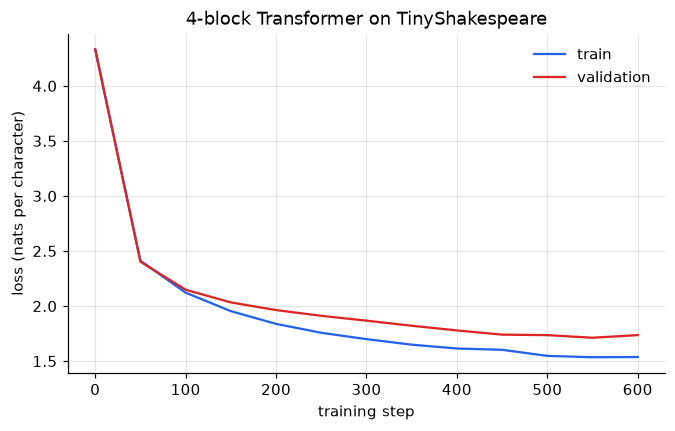

In [15]:
torch.set_num_threads(4)
model = TransformerLM(tok.vocab_size, dim=128, n_layers=4, n_heads=4)
history = mlexp.train_lm(model, train_ids, val_ids, steps=600, block_size=64)
fig, ax = plt.subplots()
ax.plot(history["step"], history["train"], label="train")
ax.plot(history["step"], history["val"], label="validation")
ax.set(xlabel="training step", ylabel="loss (nats per character)", title="4-block Transformer on TinyShakespeare")
ax.legend(frameon=False);

In [16]:
prompt = tok.encode("ROMEO:").unsqueeze(0)
torch.manual_seed(1)
print(tok.decode(model.generate(prompt, 300, temperature=0.8)[0]))

ROMEO:
Carrown sain me usul, that me, by my shall
That a virtue caused you in with your allight strikes not withifulin ouponot theresteassishousit me douckin thin yonde,
Nofanguisth whith thise thea, sty.


HATOF I the denvano thateyenoounit wilesundevous, inouse warckelesht hangunesung the healoreitutome


After a minute of CPU training, the model has learned the shape of the text: speaker names in capitals, line breaks, punctuation and many real short words. Most longer stretches are still gibberish; coherent text takes far more data, parameters and steps (chapter 12, scale).

#### Experiment: remove one block at a time

Which of the six blocks are essential, and which are habit? We take a deeper 6-block model, remove one component, retrain from scratch with the same seed and budget, and compare validation loss. Removing attention or the feed-forward layer means replacing it with a function that writes nothing into the residual stream.

This takes about 5 minutes on CPU.

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">We will remove one component at a time: position, attention, feed-forward, normalization or the residual path. Which removal hurts the most, and does any of them not hurt at all?</p><details><summary>Show what happened</summary><p>Removing the residual path is by far the worst: validation loss rises from 1.743 to 3.355, about what a model that only knows character frequencies scores. Removing attention is second (2.492). Removing normalization does not hurt at this size (1.717).</p></details></div>

In [17]:
import torch.nn as nn


class WriteNothing(nn.Module):
    """Stands in for a removed sub-layer: adds zero to the residual stream."""

    def forward(self, x):
        return torch.zeros_like(x)


def build(variant):
    torch.manual_seed(0)
    cfg = dict(dim=128, n_layers=6, n_heads=4)
    if variant == "no attention":
        m = TransformerLM(tok.vocab_size, **cfg)
        for b in m.blocks:
            b.attn = WriteNothing()
        return m
    if variant == "no feed-forward":
        return TransformerLM(tok.vocab_size, make_ffn=lambda d: WriteNothing(), **cfg)
    extra = {"full model": {}, "no position": {"rope": False},
             "no normalization": {"norm": False}, "no residual": {"residual": False}}[variant]
    return TransformerLM(tok.vocab_size, **cfg, **extra)


variants = ["full model", "no position", "no attention", "no feed-forward", "no normalization", "no residual"]
ablation = {}
for v in variants:
    h = mlexp.train_lm(build(v), train_ids, val_ids, steps=400, block_size=64, eval_every=100, log=False)
    ablation[v] = h["val"][-1]
    print(f"{v:18s} val loss {ablation[v]:.3f}")

full model         val loss 1.743


no position        val loss 2.099


no attention       val loss 2.492


no feed-forward    val loss 1.873


no normalization   val loss 1.717


no residual        val loss 3.355


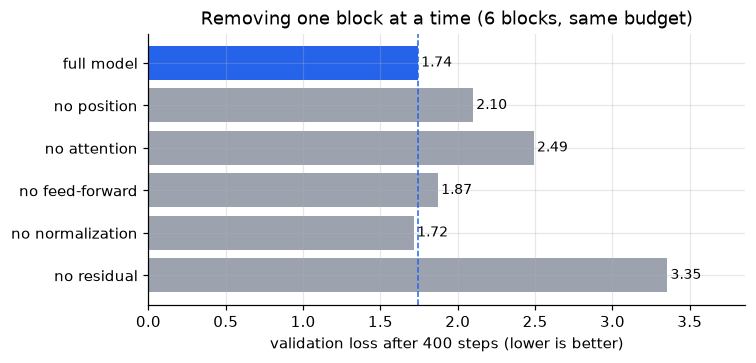

In [18]:
fig, ax = plt.subplots(figsize=(7, 3.2))
names = list(ablation)
ax.barh(names[::-1], [ablation[n] for n in names[::-1]],
        color=["#2563eb" if n == "full model" else "#9ca3af" for n in names[::-1]])
ax.axvline(ablation["full model"], color="#2563eb", lw=1, ls="--")
ax.set_xlabel("validation loss after 400 steps (lower is better)")
ax.set_title("Removing one block at a time (6 blocks, same budget)")
for i, n in enumerate(names[::-1]):
    ax.text(ablation[n] + 0.02, i, f"{ablation[n]:.2f}", va="center", fontsize=9)
ax.set_xlim(0, max(ablation.values()) * 1.15);

#### Why it worked: a post-mortem

Each claim is tagged by how strong the evidence is: **[established]** means replicated widely, **[likely]** means good evidence but open questions remain, **[speculative]** means a plausible story without decisive tests.

**The residual stream is the backbone.** In our run, removing residual connections is by far the most damaging change: the loss stays near where a model that only knows character frequencies would be. Without the identity path, gradients must pass through every layer's transformation, and a 6-block stack already struggles to train. This is the same lesson ResNet taught vision in 2015 (chapter 7). **[established]**

**Attention is the only route between tokens.** Without it the model can still learn which character tends to follow which, one token at a time, but cannot use context beyond the current character. The large drop shows how much of language modelling is context. **[established]**

**Position matters, but less than you might expect.** Removing RoPE hurts, yet the model still learns a lot. A causal mask leaks position on its own: a token at position 10 attends over 10 tokens, one at position 2 over only 2, and the model can exploit that difference. Haviv et al. (2022) showed causal language models without any position encoding can approach those with one. **[likely]**

**The feed-forward layer adds capacity, not context.** Removing it costs less than removing attention at this tiny scale, because our model is far from memorizing its data. At scale, feed-forward layers hold most of the parameters and much of the stored knowledge. **[likely]**, from interpretability work such as Geva et al. (2021).

**Normalization is insurance, not a performance boost.** In our small, short run, removing RMSNorm made no difference or helped slightly. Its value shows up in deep stacks, high learning rates and long training, where activations otherwise drift and training diverges. Small experiments are exactly where this kind of habit looks unnecessary, which is worth remembering when reading ablations. **[likely]**

**Why one design for images and text?** Attention assumes almost nothing about the data: no locality, no order. That is a weakness with little data, where the built-in assumptions of convolutions and recurrence help, and a strength with a lot of data, where learned structure beats hand-designed structure. ViT (2020) needed very large datasets to beat CNNs for this reason. **[likely]** That data-versus-assumptions trade-off recurs in almost every lineage in this book. **[speculative]** as a general law.

## Recap

<div class="mlx-box mlx-box--objectives"><p class="mlx-box__label">Recap</p><p>You should now be able to:</p><ol><li>Name the six building blocks of a modern Transformer and say what each one does.</li><li>Follow the tensor shapes from token ids to next-token logits.</li><li>Explain why a language model and a Vision Transformer share the same blocks.</li><li>Read an ablation study and judge which blocks actually carry the model.</li></ol></div>

<div class="mlx-box mlx-box--check"><p class="mlx-box__label">Check your understanding</p><details><summary>A Vision Transformer and a GPT-style model share their blocks. What actually differs between them?</summary><p>The two ends and the mask. The input is a patch embedding with learned positions instead of a token embedding with RoPE, the output is a classifier over pooled patches instead of next-token logits, and image attention has no causal mask.</p></details><details><summary>Our model still learned a lot with no position encoding. Where could it get information about order?</summary><p>From the causal mask. A token at position 10 averages over 10 tokens and one at position 2 over only 2, so the attention output carries a trace of position.</p></details><details><summary>Removing RMSNorm did not hurt our model. Why is that weak evidence that normalization is unnecessary?</summary><p>Normalization matters in deep stacks, at high learning rates and in long runs, where activations drift. A shallow, short run is exactly the setting where it looks unnecessary.</p></details></div>

## Further reading

- Vaswani et al., 2017, [Attention Is All You Need](https://arxiv.org/abs/1706.03762): the original Transformer.
- Dosovitskiy et al., 2020, [An Image is Worth 16x16 Words](https://arxiv.org/abs/2010.11929): the Vision Transformer.
- Elhage et al., 2021, [A Mathematical Framework for Transformer Circuits](https://transformer-circuits.pub/2021/framework/index.html): the residual-stream view.
- Haviv et al., 2022, [Transformer Language Models without Positional Encodings Still Learn Positional Information](https://arxiv.org/abs/2203.16634).